<a href="https://colab.research.google.com/github/pranavkerkar31/Heartline-AI/blob/main/unet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1.1: Imports

In [6]:
import os
import cv2
import torch
import matplotlib.pyplot as plt
from torchvision import transforms


Step 1.2: Set paths

In [13]:
input_dir  = "/content/dataset/input"
target_dir = "/content/dataset/target"

input_files  = sorted(os.listdir(input_dir))
target_files = sorted(os.listdir(target_dir))

print("Input files :", len(input_files))
print("Target files:", len(target_files))

assert input_files == target_files, "Filenames do not match!"
print("Filenames match")


Input files : 24
Target files: 24
Filenames match


Step 1.3: Resize image to 512x512

In [14]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])


Step 1.4: Load one paired image

In [15]:
name = input_files[0]

inp = cv2.imread(os.path.join(input_dir, name), cv2.IMREAD_GRAYSCALE)
tgt = cv2.imread(os.path.join(target_dir, name), cv2.IMREAD_GRAYSCALE)

assert inp is not None and tgt is not None, "❌ Image read failed"


Step 1.5: Apply transform

In [16]:
inp_t = transform(inp)
tgt_t = transform(tgt)

print("Input tensor :", inp_t.shape, inp_t.min().item(), inp_t.max().item())
print("Target tensor:", tgt_t.shape, tgt_t.min().item(), tgt_t.max().item())


Input tensor : torch.Size([1, 512, 512]) 0.3176470696926117 0.9921568632125854
Target tensor: torch.Size([1, 512, 512]) 0.10588235408067703 1.0


Step 1.6: Visual sanity check

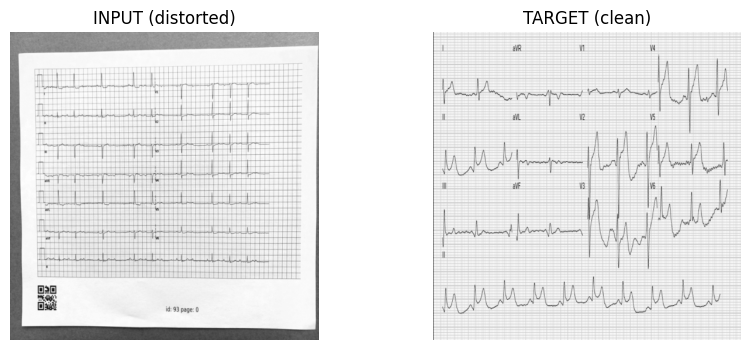

In [17]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(inp_t.squeeze(), cmap="gray")
plt.title("INPUT (distorted)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(tgt_t.squeeze(), cmap="gray")
plt.title("TARGET (clean)")
plt.axis("off")

plt.show()


Step 2.1: Required imports

In [18]:
import os
import cv2
from torch.utils.data import Dataset


Step 2.2: Define the Dataset class

In [19]:
class ECGDataset(Dataset):
    def __init__(self, input_dir, target_dir, transform=None):
        self.input_dir = input_dir
        self.target_dir = target_dir
        self.transform = transform
        self.files = sorted(os.listdir(input_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]

        inp_path = os.path.join(self.input_dir, filename)
        tgt_path = os.path.join(self.target_dir, filename)

        inp = cv2.imread(inp_path, cv2.IMREAD_GRAYSCALE)
        tgt = cv2.imread(tgt_path, cv2.IMREAD_GRAYSCALE)

        if inp is None or tgt is None:
            raise ValueError(f"Error reading {filename}")

        if self.transform:
            inp = self.transform(inp)
            tgt = self.transform(tgt)

        return inp, tgt


Step 2.3: Create the dataset object

In [20]:
dataset = ECGDataset(
    input_dir="/content/dataset/input",
    target_dir="/content/dataset/target",
    transform=transform
)

print("Dataset size:", len(dataset))


Dataset size: 24


Step 2.4: Sanity check ONE sample

In [21]:
inp, tgt = dataset[0]

print("Input shape :", inp.shape)
print("Target shape:", tgt.shape)
print("Input range :", inp.min().item(), inp.max().item())
print("Target range:", tgt.min().item(), tgt.max().item())


Input shape : torch.Size([1, 512, 512])
Target shape: torch.Size([1, 512, 512])
Input range : 0.3176470696926117 0.9921568632125854
Target range: 0.10588235408067703 1.0


Step 2.5: Visual check

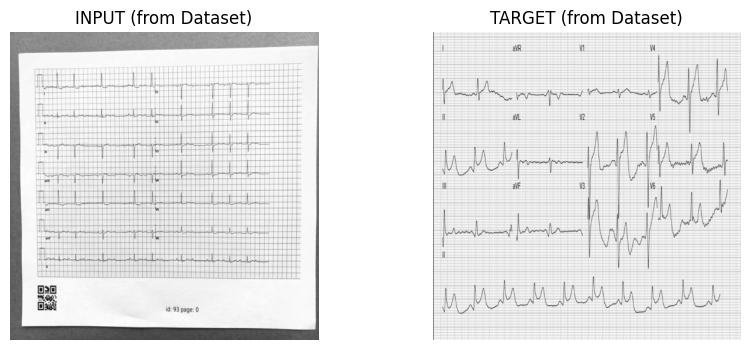

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(inp.squeeze(), cmap="gray")
plt.title("INPUT (from Dataset)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(tgt.squeeze(), cmap="gray")
plt.title("TARGET (from Dataset)")
plt.axis("off")

plt.show()


Step 3: U-Net Model Definition

In [23]:
import torch
import torch.nn as nn

# -------------------------
# Basic Convolution Block
# -------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


# -------------------------
# U-Net for ECG Restoration
# -------------------------
class ECGUNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(1, 32)
        self.enc2 = DoubleConv(32, 64)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(64, 128)

        # Decoder
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        # Output (NO sigmoid — regression)
        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))

        b = self.bottleneck(self.pool(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)


# -------------------------
# Instantiate & Sanity Check
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ECGUNet().to(device)
print("Model created successfully")

# Forward-pass sanity check
inp, _ = dataset[0]                # from STEP 2
inp = inp.unsqueeze(0).to(device)  # add batch dimension

out = model(inp)

print("Input shape :", inp.shape)
print("Output shape:", out.shape)


Model created successfully
Input shape : torch.Size([1, 1, 512, 512])
Output shape: torch.Size([1, 1, 512, 512])


Step 4: Training Setup

In [24]:
import torch
from torch.utils.data import DataLoader

# -------------------------
# DataLoader
# -------------------------
batch_size = 2  # small batch is safe for ECG & Colab

train_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

print("DataLoader ready")
print("Number of batches:", len(train_loader))


# -------------------------
# Loss Function (Regression)
# -------------------------
criterion = torch.nn.L1Loss()
print("Loss function: L1Loss")


# -------------------------
# Optimizer
# -------------------------
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)
print("Optimizer: Adam (lr=1e-4)")


# -------------------------
# One-batch Sanity Check
# -------------------------
inputs, targets = next(iter(train_loader))

inputs = inputs.to(device)
targets = targets.to(device)

outputs = model(inputs)
loss = criterion(outputs, targets)

print("Batch input shape :", inputs.shape)
print("Batch output shape:", outputs.shape)
print("Loss value        :", loss.item())


DataLoader ready
Number of batches: 12
Loss function: L1Loss
Optimizer: Adam (lr=1e-4)
Batch input shape : torch.Size([2, 1, 512, 512])
Batch output shape: torch.Size([2, 1, 512, 512])
Loss value        : 0.871614933013916


Step 5: Training

In [25]:
# -------------------------
# STEP 5: U-Net Training
# -------------------------

num_epochs = 300

model.train()

for epoch in range(num_epochs):
    running_loss = 0.0

    for inputs, targets in train_loader:
        # Move data to GPU/CPU
        inputs = inputs.to(device)
        targets = targets.to(device)

        # Zero previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = criterion(outputs, targets)

        # Backpropagation
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    # Print every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {avg_loss:.6f}")

print("✅ Training complete")


Epoch [10/300]  Loss: 0.078097
Epoch [20/300]  Loss: 0.070957
Epoch [30/300]  Loss: 0.059552
Epoch [40/300]  Loss: 0.058963
Epoch [50/300]  Loss: 0.054120
Epoch [60/300]  Loss: 0.057844
Epoch [70/300]  Loss: 0.051257
Epoch [80/300]  Loss: 0.053638
Epoch [90/300]  Loss: 0.054063
Epoch [100/300]  Loss: 0.052040
Epoch [110/300]  Loss: 0.051699
Epoch [120/300]  Loss: 0.050239
Epoch [130/300]  Loss: 0.052397
Epoch [140/300]  Loss: 0.052336
Epoch [150/300]  Loss: 0.052094
Epoch [160/300]  Loss: 0.050664
Epoch [170/300]  Loss: 0.051899
Epoch [180/300]  Loss: 0.049982
Epoch [190/300]  Loss: 0.052687
Epoch [200/300]  Loss: 0.050774
Epoch [210/300]  Loss: 0.050491
Epoch [220/300]  Loss: 0.051077
Epoch [230/300]  Loss: 0.050669
Epoch [240/300]  Loss: 0.050452
Epoch [250/300]  Loss: 0.050366
Epoch [260/300]  Loss: 0.050443
Epoch [270/300]  Loss: 0.049972
Epoch [280/300]  Loss: 0.049563
Epoch [290/300]  Loss: 0.050853
Epoch [300/300]  Loss: 0.052424
✅ Training complete
